#### Notebook for plotting results of reweighting parameters including sigma

In [2]:
import importlib
from RSA_nD_tuner import *
import RSA_nD_tuner
importlib.reload(RSA_nD_tuner)
from RSA_nD_tuner import *

### Flow map
Now that we have a grid over the $(a,b)$-plane we can visualize the loss landscape. Below the red dot represents the base parameterization from which all other points are reweighed from. The green start is the target parameterization where the loss function (in this case the psuedo-$\chi^2$) should be at a minimum. The arrow represent the gradients of $a$ and $b$ at each grid point.

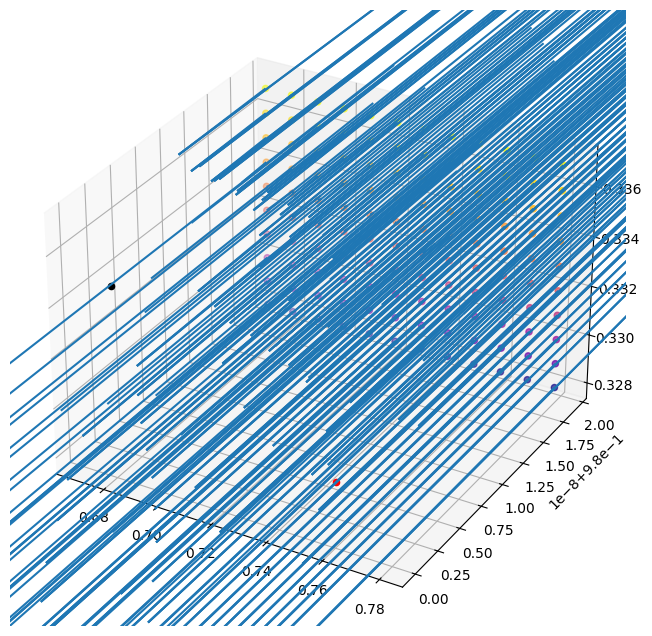

In [3]:
# Plots of reweighting loss landscape
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

# Choose data number as described in temp_results/Flow_map_nD/data_description.txt
plot_nm = '37'

magnitudes = np.load(f'temp_results/Flow_map_nD/magnitudes_{plot_nm}.npy')
a_b_gradients = np.load(f'temp_results/Flow_map_nD/gradients_{plot_nm}.npy')
loss_grid = np.load(f'temp_results/Flow_map_nD/loss_grid_{plot_nm}.npy')
mu_sigmamu = np.load(f'temp_results/Flow_map_nD/mu_{plot_nm}.npy')
Neff = np.load(f'temp_results/Flow_map_nD/Neff_{plot_nm}.npy')
mu = mu_sigmamu[:,0]
sigmamu = mu_sigmamu[:,1]
a_b_c = np.load(f'temp_results/Flow_map_nD/ad_bd_sig_{plot_nm}.npy')


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ad = a_b_c[:,0]
bd = a_b_c[:,1]
sig = a_b_c[:,2]

if plot_nm == '19':
    scale = 10e2
if plot_nm == '20':
    scale = 10e2
if plot_nm == '21':
    scale = 10e3
if plot_nm == '22':
    scale = 5e3
if plot_nm == '23':
    scale = 5e3
if plot_nm == '24':
    scale = 5e3
if plot_nm == '25':
    scale = 5e3
if plot_nm == '26':
    scale = 5e3
if plot_nm == '27':
    scale = 5e2
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.58,0.88,0.31, label = 'target', c='red')
if plot_nm == '28':
    scale = 5e3
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.58,0.88,0.31, label = 'target', c='red')
if plot_nm == '29':
    scale = 5e3
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.58,0.88,0.31, label = 'target', c='red')
if plot_nm == '30':
    scale = 5e3
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.58,0.88,0.31, label = 'target', c='red')
if plot_nm == '31':
    scale = 5e2
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.58,0.88,0.31, label = 'target', c='red')
if plot_nm == '32':
    scale = 5e2
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.58,0.88,0.31, label = 'target', c='red')
if plot_nm == '33':
    scale = 5e3
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.58,0.88,0.31, label = 'target', c='red')
if plot_nm == '34':
    scale = 5e3
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.78,0.88,0.33, label = 'target', c='red')
if plot_nm == '35':
    scale = 5e3
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.78,0.88,0.33, label = 'target', c='red')
if plot_nm == '36':
    scale = 2e4
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.76,0.98,0.33, label = 'target', c='red')
if plot_nm == '37':
    scale = 2e4
    ax.scatter(xs=0.68,ys=0.98,zs=0.335, label = 'base', c= 'black')
    ax.scatter(0.76,0.98,0.33, label = 'target', c='red')

g1,g2,g3 =  -a_b_gradients[:,0], -a_b_gradients[:,1], -a_b_gradients[:,2]
ax.quiver(ad,bd,sig,g1/scale,g2/scale,g3/scale)
ax.scatter(xs=ad, ys=bd, zs=sig, c=np.log10((loss_grid)), cmap='plasma', s=20)  # 's' is size, 'c' is color



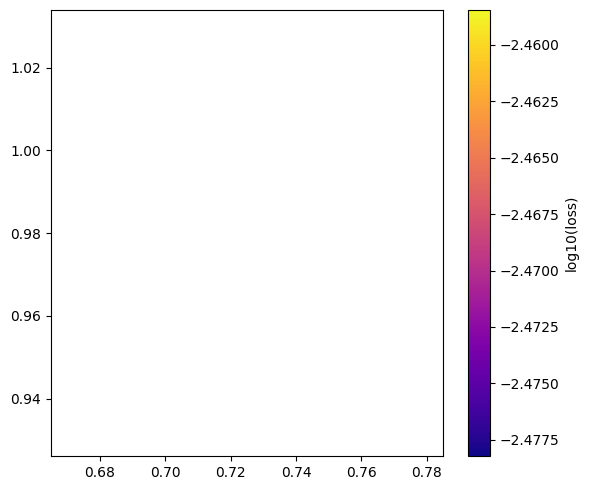

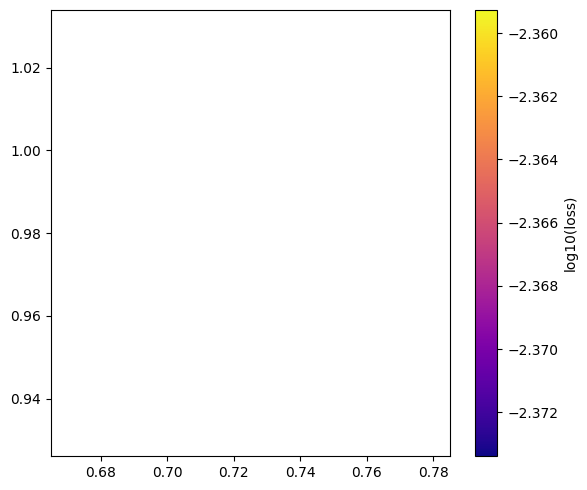

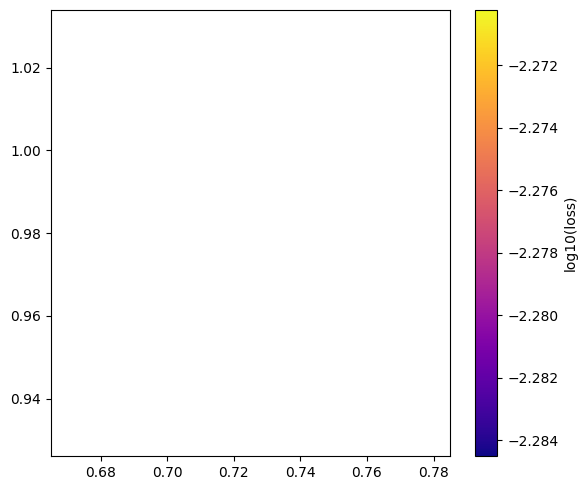

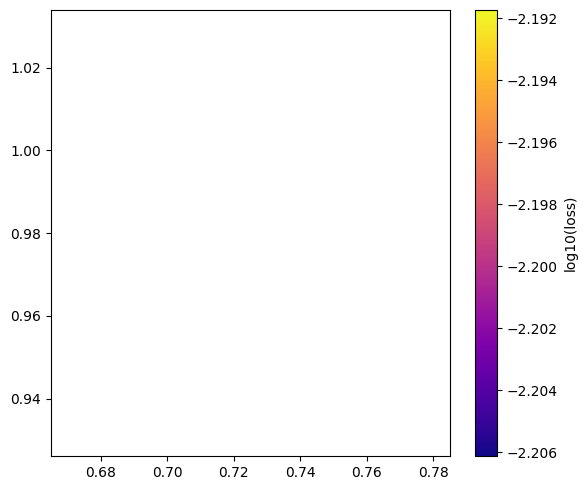

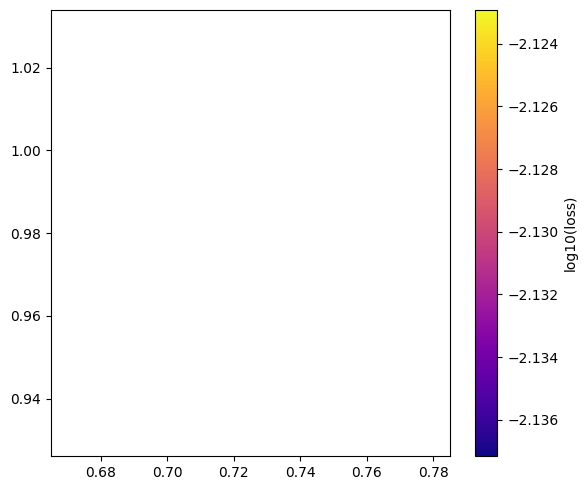

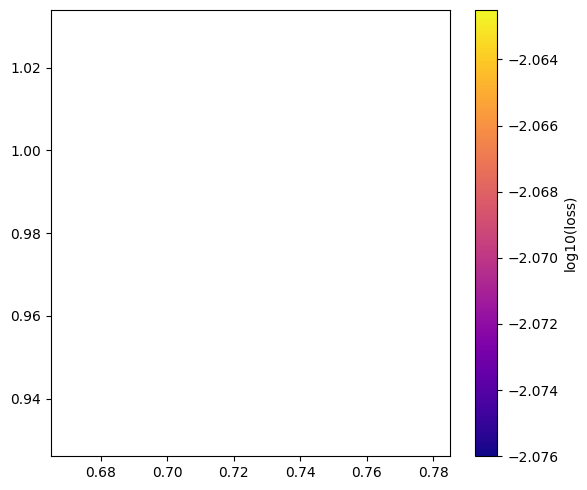

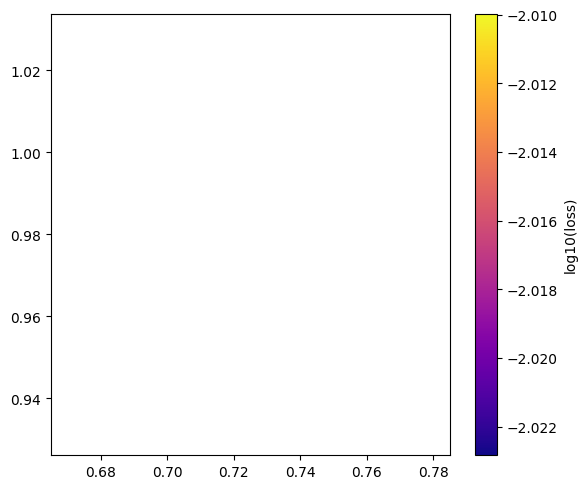

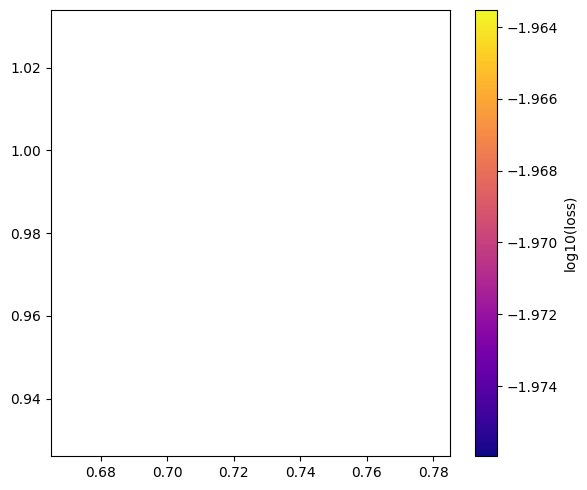

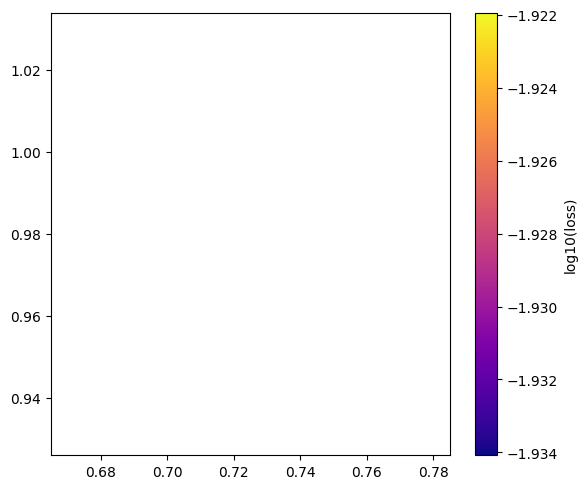

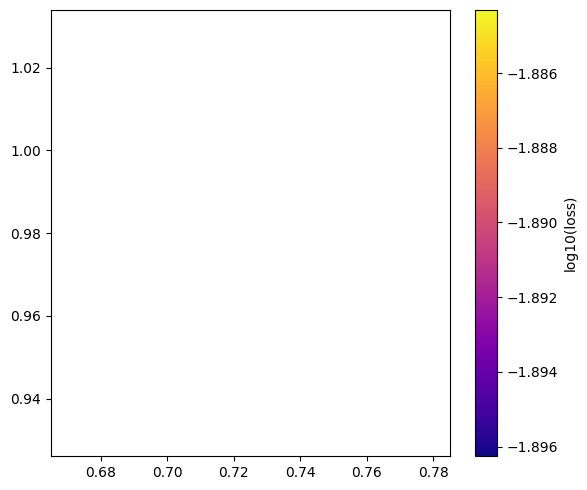

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Extract unique values for au
aus = np.unique(a_b_c[:, 2])


for a_value in aus:
    plt.figure(figsize=(6, 5))
    
    # Mask for current au slice
    mask = a_b_c[:, 2] == a_value
    ad = a_b_c[mask, 0]
    bd = a_b_c[mask, 1]
    ad_bd = np.vstack([ad,bd]).T
    a_b_grad_plot = a_b_gradients[mask]

    # Choose what to plot: mu/loss/N_eff
    loss_plot = np.log10((loss_grid))[mask]
    # loss_plot = ((mu))[mask][:]
    # loss_plot = ((Neff))[mask][:]

    # Get unique sorted grid values
    ad_unique = np.unique(ad)
    bd_unique = np.unique(bd)
    ad_grid, bd_grid = np.meshgrid(ad_unique, bd_unique, indexing='ij')

    # Reshape the loss values to fit the 2D grid
    loss_2d = loss_plot.reshape(len(ad_unique), len(bd_unique))
    # loss_2d -= (np.min(loss_2d))
    # loss_2d = np.log(loss_2d + 1e-1)

    # Plot
    cmap = plt.get_cmap('plasma')
    pc = plt.pcolormesh(ad_grid, bd_grid, loss_2d, shading='auto', cmap=cmap)
    if plot_nm == '19':
        for point, gradient in zip(ad_bd, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[1]/scale, head_width=0.03, head_length=0.04, fc='k', ec='k')
        plt.title(f'sigma = {a_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.88, sigma = 0.335')
    if plot_nm == '20':
        for point, gradient in zip(ad_bd, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[1]/scale, head_width=0.03, head_length=0.04, fc='k', ec='k')
        plt.title(f'sigma = {a_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.88, sigma = 0.335')
    
    if plot_nm == '21':
        for point, gradient in zip(ad_bd, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[1]/scale, head_width=0.03, head_length=0.04, fc='k', ec='k')
        plt.title(f'sigma = {a_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.88, sigma = 0.335')
        plt.plot(0.78, 0.88, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.98, marker='o', color='black', markersize=10, zorder=5)
    
    if plot_nm == '22':
        scale = 3e2
        for point, gradient in zip(ad_bd, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[1]/scale, head_width=0.003, head_length=0.004, fc='k', ec='k')
        plt.title(f'sigma = {a_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.88, sigma = 0.335')
    
    
    if plot_nm == '23':
        scale = 3e2
        for point, gradient in zip(ad_bd, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[1]/scale, head_width=0.003, head_length=0.004, fc='k', ec='k')
        plt.title(f'sigma = {a_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
        plt.plot(0.58, 0.88, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.98, marker='o', color='black', markersize=10, zorder=5)

    if plot_nm == '26':
        scale = 3e2
        for point, gradient in zip(ad_bd, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[1]/scale, head_width=0.003, head_length=0.004, fc='k', ec='k')
        plt.title(f'sigma = {a_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.88, sigma = 0.325')
        plt.plot(0.58, 0.88, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.98, marker='o', color='black', markersize=10, zorder=5)

    if plot_nm == '27':
        scale = 3e2
        for point, gradient in zip(ad_bd, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[1]/scale, head_width=0.003, head_length=0.004, fc='k', ec='k')
        plt.title(f'sigma = {a_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
        plt.plot(0.58, 0.88, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.98, marker='o', color='black', markersize=10, zorder=5)

    if plot_nm == '28':
        scale = 3e2
        for point, gradient in zip(ad_bd, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[1]/scale, head_width=0.003, head_length=0.004, fc='k', ec='k')
        plt.title(f'sigma = {a_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
        plt.plot(0.58, 0.88, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.98, marker='o', color='black', markersize=10, zorder=5)

    sig_label = r"$\ln \left( \left| \frac{1 - \mu}{\sigma_{1 - \mu}} \right| \right)$"
    plt.colorbar(label='log10(loss)')
    # plt.colorbar(label=sig_label)
    # plt.colorbar(label='Neff')
    # plt.title(f'a_u = {a_value:.2f}')
    # plt.xlabel('a_d')
    # plt.ylabel('b_d')
    plt.tight_layout()
    # plt.savefig(f'temp_results/Flow_map_nD/plots/sig3_{a_value:.4f}.png')
    plt.show()


6.114139e-07 -1.0532539e-07 -0.00010533881 0.78 0.337


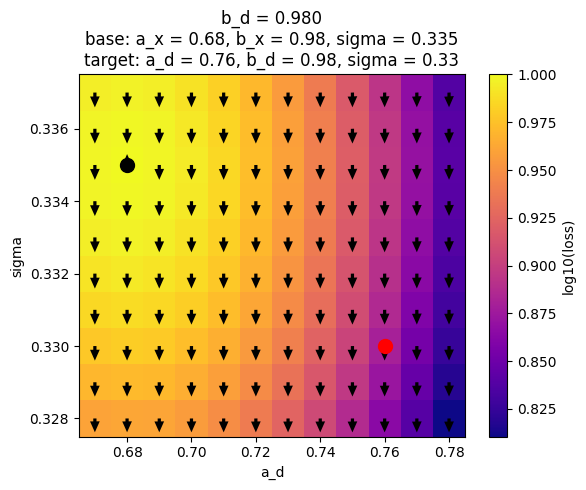

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Extract unique values for au
bds = np.unique(a_b_c[:, 1])
scale = 3e3
for b_value in bds:
    plt.figure(figsize=(6, 5))
    
    # Mask for current au slice
    mask = a_b_c[:, 1] == b_value
    ad = a_b_c[mask, 0]
    au = a_b_c[mask, 2]
    ad_au = np.vstack([ad,au]).T
    a_b_grad_plot = a_b_gradients[mask]


    # loss_plot = np.log10((loss_grid))[mask]
    # loss_plot = ((mu))[mask][:]
    loss_plot = ((Neff))[mask][:]

    # Get unique sorted grid values
    ad_unique = np.unique(ad)
    au_unique = np.unique(au)
    ad_grid, au_grid = np.meshgrid(ad_unique, au_unique, indexing='ij')

    # Reshape the loss values to fit the 2D grid
    loss_2d = loss_plot.reshape(len(ad_unique), len(au_unique))
    # loss_2d -= (np.min(loss_2d))
    # loss_2d = np.log(loss_2d + 1e-1)

    # Plot
    cmap = plt.get_cmap('plasma')
    pc = plt.pcolormesh(ad_grid, au_grid, loss_2d, shading='auto', cmap=cmap)

    if plot_nm == '21':
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.004, fc='k', ec='k')
        plt.plot(0.68, 0.335, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.78, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.88, sigma = 0.335')

    if plot_nm == '22':
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.004, fc='k', ec='k')
        plt.plot(0.68, 0.335, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.78, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.88, sigma = 0.335')
    
    if plot_nm == '23':
        scale = 8e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.58, 0.31, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
        
    if plot_nm == '24':
        scale = 8e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.78, 0.325, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.98, sigma = 0.325')
    if plot_nm == '25':
        scale = 8e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.78, 0.325, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.98, sigma = 0.325')
    if plot_nm == '26':
        scale = 8e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.78, 0.325, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.98, sigma = 0.325')
    if plot_nm == '27':
        scale = 8e2
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.58, 0.31, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
    
    if plot_nm == '29':
        scale = 4e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.58, 0.31, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
    
    if plot_nm == '30':
        scale = 4e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.58, 0.31, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
    if plot_nm == '31':
        scale = 4e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.58, 0.31, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
    
    if plot_nm == '32':
        scale = 4e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.58, 0.31, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
        print(-gradient[0]/scale, -gradient[1]/scale, -gradient[2]/scale)

    if plot_nm == '33':
        scale = 4e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.001, fc='k', ec='k')
        plt.plot(0.58, 0.31, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.58, b_d = 0.88, sigma = 0.31')
        print(-gradient[0]/scale, -gradient[1]/scale, -gradient[2]/scale)

    if plot_nm == '34':
        scale = 8e3
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.0003, fc='k', ec='k')
        plt.plot(0.78, 0.33, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.88, sigma = 0.33')
        # print(-gradient[0]/scale, -gradient[1]/scale, -gradient[2]/scale)
        print(-gradient[0]/scale, -gradient[1]/scale, -gradient[2]/scale, point[0], point[1])

    if plot_nm == '35':
        scale = 1e4
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.0003, head_width=0.003, head_length=0.0003, fc='k', ec='k')
        plt.plot(0.78, 0.33, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.78, b_d = 0.88, sigma = 0.33')
        print(-gradient[0]/scale, -gradient[1]/scale, -gradient[2]/scale, point[0], point[1])
        
    if plot_nm == '36':
        scale = 1e4
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.0003, head_width=0.003, head_length=0.0003, fc='k', ec='k')
        plt.plot(0.76, 0.33, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.76, b_d = 0.98, sigma = 0.33')
        print(-gradient[0]/scale, -gradient[1]/scale, -gradient[2]/scale, point[0], point[1])
    
    if plot_nm == '37':
        scale = 1e4
        for point, gradient in zip(ad_au, a_b_grad_plot):
            plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.0003, head_width=0.003, head_length=0.0003, fc='k', ec='k')
        plt.plot(0.76, 0.33, marker='o', color='red', markersize=10, zorder=5)
        plt.plot(0.68, 0.335, marker='o', color='black', markersize=10, zorder=5)
        plt.title(f'b_d = {b_value:.3f}\n'
            f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
            f'target: a_d = 0.76, b_d = 0.98, sigma = 0.33')
        print(-gradient[0]/scale, -gradient[1]/scale, -gradient[2]/scale, point[0], point[1])
    

    sig_label = r"$\ln \left( \left| \frac{1 - \mu}{\sigma_{1 - \mu}} \right| \right)$"
    plt.colorbar(label='log10(loss)')
    # plt.colorbar(label=sig_label)
    # plt.colorbar(label='Neff')
    plt.xlabel(r'a_d')
    plt.ylabel(r'sigma')
    plt.tight_layout()
    plt.savefig(f'temp_results/Flow_map_nD/plots/36sigma.png')
    plt.show()

# print(loss_2d[3])
# print(a_b_grad_plot)

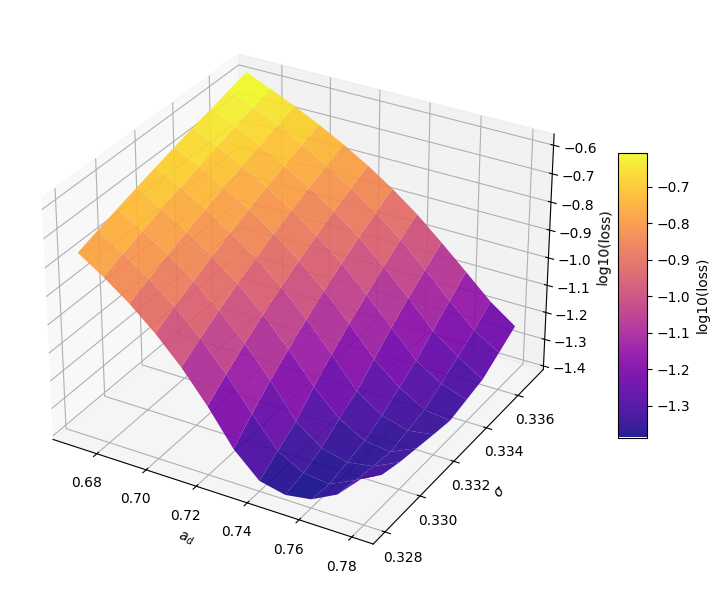

In [6]:



import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

bds = np.unique(a_b_c[:, 1])
scale = 3e3

for b_value in bds:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Mask for current b_value
    mask = a_b_c[:, 1] == b_value
    ad = a_b_c[mask, 0]
    au = a_b_c[mask, 2]
    a_b_grad_plot = a_b_gradients[mask]
    loss_plot = np.log10(loss_grid[mask])

    # Create 2D grid
    ad_unique = np.unique(ad)
    au_unique = np.unique(au)
    ad_grid, au_grid = np.meshgrid(ad_unique, au_unique, indexing='ij')
    loss_2d = loss_plot.reshape(len(ad_unique), len(au_unique))

    # Surface plot
    surf = ax.plot_surface(ad_grid, au_grid, loss_2d, cmap='plasma', alpha=0.9)
    fig.colorbar(surf, shrink=0.5, aspect=10, label='log10(loss)')

    # Arrows (optional)
    if plot_nm == '22':
        for point, gradient in zip(np.vstack([ad, au]).T, a_b_grad_plot):
            ax.quiver(point[0], point[1],  # x, y
                      loss_plot[0],        # z base
                      -gradient[0]/scale,  # dx
                      -gradient[2]/scale,  # dy
                      0,                   # dz (optional, or compute ∂L/∂z if available)
                      color='k', linewidth=0.8, arrow_length_ratio=0.15)

        ax.scatter(0.68, 0.335, np.min(loss_plot), color='red', s=50, label='base')
        ax.scatter(0.78, 0.335, np.min(loss_plot), color='black', s=50, label='target')
        ax.set_title(f'sigma = {b_value:.3f}\nbase/target trajectory')
        ax.legend()

    ax.set_xlabel(r'$a_d$')
    ax.set_ylabel(r'$\sigma$')
    ax.set_zlabel('log10(loss)')
    plt.tight_layout()
    plt.show()
